# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [60]:
# Importing packages
import pickle as pkl             # Needed to import the pkl files
import numpy  as np
import matplotlib.pyplot as plt

# 1. Loading data

In [14]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
    
with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics

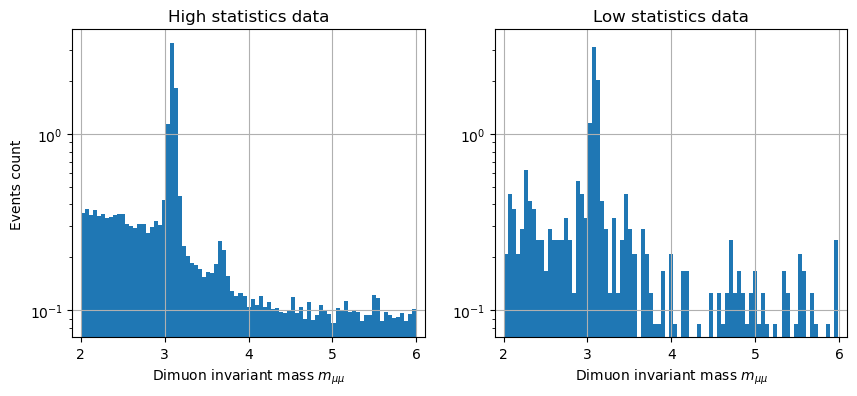

In [50]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)

fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=bin_num)
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
#ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

Following the instructions of the README file, we will model the bare background (and with that I mean without the
peak of the J/$\Psi$ resonance) with Chebychev polynomial of order three. 
Being honest, they are not super clear about what this is so I had to dig inside the CERN definitions of tools they use to fit.
[There](https://root.cern/doc/master/ChebyshevPol_8h_source.html), at line 66, we see how the third order Chebyshev polynomial is evaluated.
Apparently, it returns
\begin{equation}
    c_3 \cdot (4x^3-3x) + c_2\cdot(2x^2 - 1) + c_1\cdot x + c_0
\end{equation}
but this has four parameters! Given the knowledge they seem to have on Chebyshev parameters, I think they simply call "order 3" the polynomial that needs three parameters, thus order 2, which returns
\begin{equation}
    c_2\cdot(2x^2 - 1) + c_1\cdot x + c_0
\end{equation}

In [104]:
def cheb3(x, params):
    a3, a2, a1 = params
    return a3*(4*x**3-3*x) + a2*(2*x**2-1) + a1*x

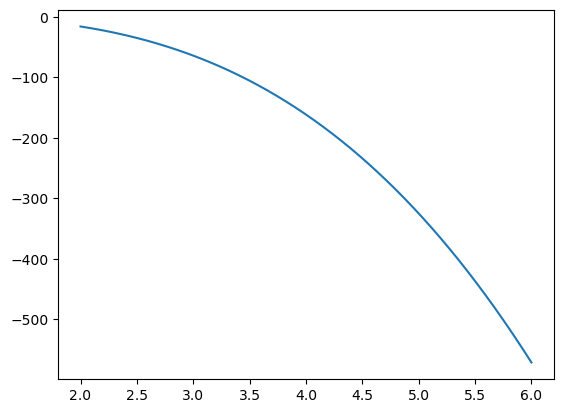

In [106]:
xs = np.linspace(2,6,1000)
ys = []
params = [-0.7, 0.3, -0.03]
for x in xs:
    ys.append(cheb3(x,params))

plt.plot(xs,ys)